In [1]:
from google.colab import files

uploaded = files.upload()

Saving RTA Dataset.csv to RTA Dataset.csv


In [2]:
import pandas as pd
df = pd.read_csv("RTA Dataset.csv")
df.head()
print(df.shape)
print(df.columns)

(12316, 32)
Index(['Time', 'Day_of_week', 'Age_band_of_driver', 'Sex_of_driver',
       'Educational_level', 'Vehicle_driver_relation', 'Driving_experience',
       'Type_of_vehicle', 'Owner_of_vehicle', 'Service_year_of_vehicle',
       'Defect_of_vehicle', 'Area_accident_occured', 'Lanes_or_Medians',
       'Road_allignment', 'Types_of_Junction', 'Road_surface_type',
       'Road_surface_conditions', 'Light_conditions', 'Weather_conditions',
       'Type_of_collision', 'Number_of_vehicles_involved',
       'Number_of_casualties', 'Vehicle_movement', 'Casualty_class',
       'Sex_of_casualty', 'Age_band_of_casualty', 'Casualty_severity',
       'Work_of_casuality', 'Fitness_of_casuality', 'Pedestrian_movement',
       'Cause_of_accident', 'Accident_severity'],
      dtype='object')


In [3]:
df['Accident_severity'].value_counts()
df['Accident_severity'].value_counts(normalize=True) * 100

,proportion
Accident_severity,
Slight Injury,84.564794
Serious Injury,14.152322
Fatal injury,1.282884


In [4]:
df.isnull().sum()

,0
Time,0
Day_of_week,0
Age_band_of_driver,0
Sex_of_driver,0
Educational_level,741
Vehicle_driver_relation,579
Driving_experience,829
Type_of_vehicle,950
Owner_of_vehicle,482
Service_year_of_vehicle,3928


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12316 entries, 0 to 12315
Data columns (total 32 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   Time                         12316 non-null  object
 1   Day_of_week                  12316 non-null  object
 2   Age_band_of_driver           12316 non-null  object
 3   Sex_of_driver                12316 non-null  object
 4   Educational_level            11575 non-null  object
 5   Vehicle_driver_relation      11737 non-null  object
 6   Driving_experience           11487 non-null  object
 7   Type_of_vehicle              11366 non-null  object
 8   Owner_of_vehicle             11834 non-null  object
 9   Service_year_of_vehicle      8388 non-null   object
 10  Defect_of_vehicle            7889 non-null   object
 11  Area_accident_occured        12077 non-null  object
 12  Lanes_or_Medians             11931 non-null  object
 13  Road_allignment              12

In [6]:
print(df.duplicated().sum())
df['Accident_severity'].value_counts()

0


,count
Accident_severity,
Slight Injury,10415
Serious Injury,1743
Fatal injury,158


In [7]:
df_clean = df.copy()
for col in df_clean.columns:
    if df_clean[col].dtype == 'object':
        df_clean[col] = df_clean[col].fillna('Unknown')

In [8]:
df_clean.isnull().sum()

,0
Time,0
Day_of_week,0
Age_band_of_driver,0
Sex_of_driver,0
Educational_level,0
Vehicle_driver_relation,0
Driving_experience,0
Type_of_vehicle,0
Owner_of_vehicle,0
Service_year_of_vehicle,0


In [9]:
df_clean.head()

,Time,Day_of_week,Age_band_of_driver,Sex_of_driver,Educational_level,Vehicle_driver_relation,Driving_experience,Type_of_vehicle,Owner_of_vehicle,Service_year_of_vehicle,...,Vehicle_movement,Casualty_class,Sex_of_casualty,Age_band_of_casualty,Casualty_severity,Work_of_casuality,Fitness_of_casuality,Pedestrian_movement,Cause_of_accident,Accident_severity
0,17:02:00,Monday,18-30,Male,Above high school,Employee,1-2yr,Automobile,Owner,Above 10yr,...,Going straight,na,na,na,na,Unknown,Unknown,Not a Pedestrian,Moving Backward,Slight Injury
1,17:02:00,Monday,31-50,Male,Junior high school,Employee,Above 10yr,Public (> 45 seats),Owner,5-10yrs,...,Going straight,na,na,na,na,Unknown,Unknown,Not a Pedestrian,Overtaking,Slight Injury
2,17:02:00,Monday,18-30,Male,Junior high school,Employee,1-2yr,Lorry (41?100Q),Owner,Unknown,...,Going straight,Driver or rider,Male,31-50,3,Driver,Unknown,Not a Pedestrian,Changing lane to the left,Serious Injury
3,1:06:00,Sunday,18-30,Male,Junior high school,Employee,5-10yr,Public (> 45 seats),Governmental,Unknown,...,Going straight,Pedestrian,Female,18-30,3,Driver,Normal,Not a Pedestrian,Changing lane to the right,Slight Injury
4,1:06:00,Sunday,18-30,Male,Junior high school,Employee,2-5yr,Unknown,Owner,5-10yrs,...,Going straight,na,na,na,na,Unknown,Unknown,Not a Pedestrian,Overtaking,Slight Injury


In [10]:
df_clean.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12316 entries, 0 to 12315
Data columns (total 32 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   Time                         12316 non-null  object
 1   Day_of_week                  12316 non-null  object
 2   Age_band_of_driver           12316 non-null  object
 3   Sex_of_driver                12316 non-null  object
 4   Educational_level            12316 non-null  object
 5   Vehicle_driver_relation      12316 non-null  object
 6   Driving_experience           12316 non-null  object
 7   Type_of_vehicle              12316 non-null  object
 8   Owner_of_vehicle             12316 non-null  object
 9   Service_year_of_vehicle      12316 non-null  object
 10  Defect_of_vehicle            12316 non-null  object
 11  Area_accident_occured        12316 non-null  object
 12  Lanes_or_Medians             12316 non-null  object
 13  Road_allignment              12

In [11]:
print(df_clean.isnull().sum().sum())

0


**Accident severity**

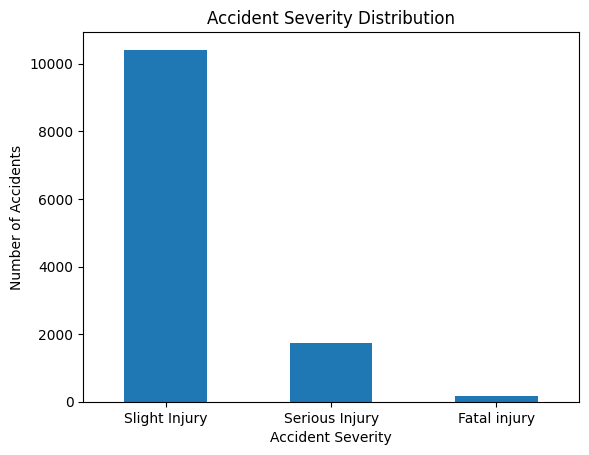

In [12]:
import matplotlib.pyplot as plt

df_clean['Accident_severity'].value_counts().plot(kind='bar')

plt.title('Accident Severity Distribution')
plt.xlabel('Accident Severity')
plt.ylabel('Number of Accidents')
plt.xticks(rotation=0)
plt.show()

**Which day has more accidents?**

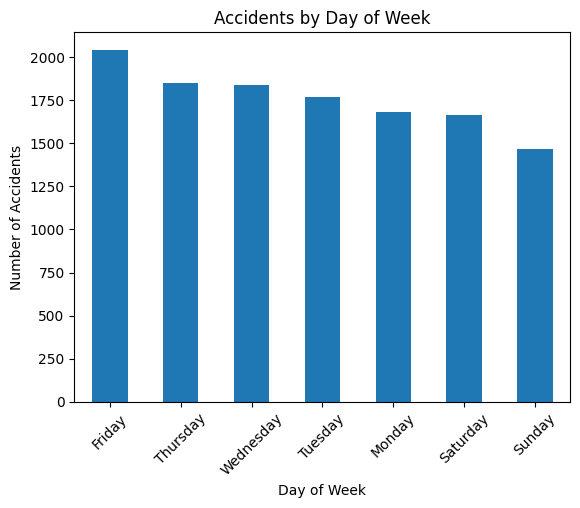

In [13]:
df_clean['Day_of_week'].value_counts().plot(kind='bar')

plt.title('Accidents by Day of Week')
plt.xlabel('Day of Week')
plt.ylabel('Number of Accidents')
plt.xticks(rotation=45)
plt.show()

**Accident severity vs number of vehicles**

In [14]:
df_clean.groupby('Accident_severity')['Number_of_vehicles_involved'].mean()

,Number_of_vehicles_involved
Accident_severity,
Fatal injury,1.797468
Serious Injury,1.895009
Slight Injury,2.068747


In [15]:
print(df_clean.groupby('Accident_severity')['Number_of_casualties'].mean())

Accident_severity
Fatal injury      2.341772
Serious Injury    1.535284
Slight Injury     1.538262
Name: Number_of_casualties, dtype: float64


In [16]:
print(df_clean['Day_of_week'].value_counts())

Day_of_week
Friday       2041
Thursday     1851
Wednesday    1840
Tuesday      1770
Monday       1681
Saturday     1666
Sunday       1467
Name: count, dtype: int64


**Create an Hour column**

In [17]:
df_clean['Time'] = pd.to_datetime(
    df_clean['Time'],
    format='%H:%M:%S',
    errors='coerce'
)
df_clean['Hour'] = df_clean['Time'].dt.hour
df_clean[['Time', 'Hour']].head()

,Time,Hour
0,1900-01-01 17:02:00,17
1,1900-01-01 17:02:00,17
2,1900-01-01 17:02:00,17
3,1900-01-01 01:06:00,1
4,1900-01-01 01:06:00,1


In [18]:
df_clean['Hour'].value_counts().sort_index()

,count
Hour,
0,206
1,134
2,84
3,84
4,91
5,76
6,214
7,532
8,828


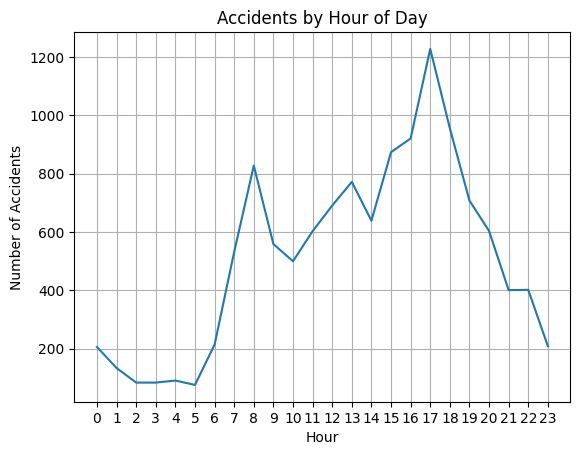

In [19]:
df_clean['Hour'].value_counts().sort_index().plot(kind='line')

plt.title('Accidents by Hour of Day')
plt.xlabel('Hour')
plt.ylabel('Number of Accidents')
plt.xticks(range(0, 24))
plt.grid()
plt.show()

**Severity by road surface condition**

In [20]:
pd.crosstab(
    df_clean['Road_surface_conditions'],
    df_clean['Accident_severity'],
    normalize='index'
) * 100

Accident_severity,Fatal injury,Serious Injury,Slight Injury
Road_surface_conditions,,,
Dry,1.295503,14.261242,84.443255
Flood over 3cm. deep,0.000000,0.000000,100.000000
Snow,0.000000,5.714286,94.285714
Wet or damp,1.274105,14.015152,84.710744


**Severity by weather**

In [21]:
pd.crosstab(
    df_clean['Weather_conditions'],
    df_clean['Accident_severity'],
    normalize='index'
) * 100

Accident_severity,Fatal injury,Serious Injury,Slight Injury
Weather_conditions,,,
Cloudy,0.000000,6.400000,93.600000
Fog or mist,0.000000,10.000000,90.000000
Normal,1.341548,14.647719,84.010732
Other,0.000000,9.459459,90.540541
Raining,1.728024,11.870774,86.401202
Raining and Windy,0.000000,5.000000,95.000000
Snow,0.000000,8.196721,91.803279
Unknown,0.000000,17.465753,82.534247
Windy,0.000000,16.326531,83.673469


**Severity by light condition**

In [22]:
pd.crosstab(
    df_clean['Light_conditions'],
    df_clean['Accident_severity'],
    normalize='index'
) * 100

Accident_severity,Fatal injury,Serious Injury,Slight Injury
Light_conditions,,,
Darkness - lights lit,2.008521,14.150943,83.840536
Darkness - lights unlit,0.000000,17.500000,82.500000
Darkness - no lighting,2.604167,25.520833,71.875000
Daylight,0.988861,13.889520,85.121619


In [23]:
pd.crosstab(
    df_clean['Light_conditions'],
    df_clean['Accident_severity']
)

Accident_severity,Fatal injury,Serious Injury,Slight Injury
Light_conditions,,,
Darkness - lights lit,66,465,2755
Darkness - lights unlit,0,7,33
Darkness - no lighting,5,49,138
Daylight,87,1222,7489


**Severity by driving experience**

In [24]:
pd.crosstab(
    df_clean['Driving_experience'],
    df_clean['Accident_severity'],
    normalize='index'
) * 100

Accident_severity,Fatal injury,Serious Injury,Slight Injury
Driving_experience,,,
1-2yr,1.195900,12.984055,85.820046
2-5yr,1.760429,14.580941,83.658630
5-10yr,1.219150,13.737734,85.043116
Above 10yr,1.282051,14.279399,84.438550
Below 1yr,0.521610,15.424739,84.053651
No Licence,0.000000,11.016949,88.983051
Unknown,1.568154,14.837153,83.594692
unknown,3.030303,18.181818,78.787879


In [25]:
pd.crosstab(
    df_clean['Driving_experience'],
    df_clean['Accident_severity']
)

Accident_severity,Fatal injury,Serious Injury,Slight Injury
Driving_experience,,,
1-2yr,21,228,1507
2-5yr,46,381,2186
5-10yr,41,462,2860
Above 10yr,29,323,1910
Below 1yr,7,207,1128
No Licence,0,13,105
Unknown,13,123,693
unknown,1,6,26


**Weather conditions**

In [26]:
pd.crosstab(
    df_clean['Weather_conditions'],
    df_clean['Accident_severity'],
    normalize='index'
) * 100

Accident_severity,Fatal injury,Serious Injury,Slight Injury
Weather_conditions,,,
Cloudy,0.000000,6.400000,93.600000
Fog or mist,0.000000,10.000000,90.000000
Normal,1.341548,14.647719,84.010732
Other,0.000000,9.459459,90.540541
Raining,1.728024,11.870774,86.401202
Raining and Windy,0.000000,5.000000,95.000000
Snow,0.000000,8.196721,91.803279
Unknown,0.000000,17.465753,82.534247
Windy,0.000000,16.326531,83.673469


In [27]:
for col in df_clean.select_dtypes(include='object').columns:
    values = df_clean[col].dropna().unique()
    lower_values = {}

    for value in values:
        key = value.lower()
        lower_values.setdefault(key, []).append(value)

    duplicates = {
        key: vals for key, vals in lower_values.items()
        if len(vals) > 1
    }

    if duplicates:
        print("\n", col)
        print(duplicates)


 Driving_experience
{'unknown': ['Unknown', 'unknown']}


In [28]:
df_clean['Driving_experience'] = df_clean['Driving_experience'].replace(
    'unknown', 'Unknown'
)

In [29]:
df_clean['Driving_experience'].value_counts()

,count
Driving_experience,
5-10yr,3363
2-5yr,2613
Above 10yr,2262
1-2yr,1756
Below 1yr,1342
Unknown,862
No Licence,118


**Analyze causes of accidents**

In [30]:
df_clean['Cause_of_accident'].value_counts()

,count
Cause_of_accident,
No distancing,2263
Changing lane to the right,1808
Changing lane to the left,1473
Driving carelessly,1402
No priority to vehicle,1207
Moving Backward,1137
No priority to pedestrian,721
Other,456
Overtaking,430


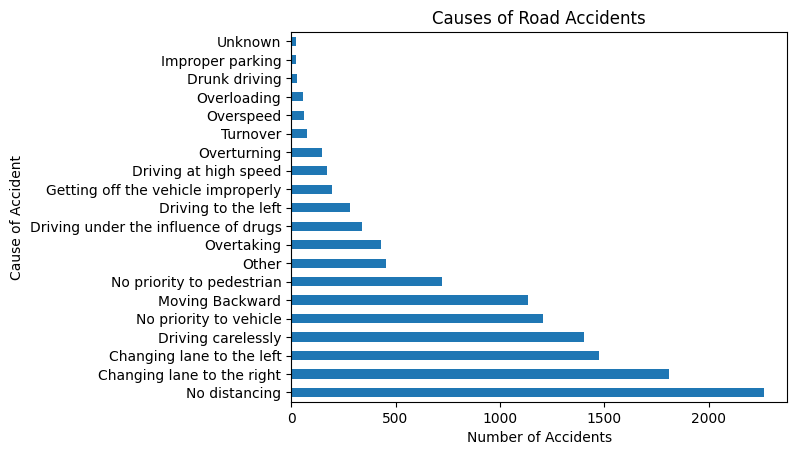

In [31]:
df_clean['Cause_of_accident'].value_counts().plot(kind='barh')

plt.title('Causes of Road Accidents')
plt.xlabel('Number of Accidents')
plt.ylabel('Cause of Accident')
plt.show()

**Find the most severe causes**

In [32]:
cause_severity = pd.crosstab(
    df_clean['Cause_of_accident'],
    df_clean['Accident_severity'],
    normalize='index'
) * 100

cause_severity.sort_values(
    by=['Fatal injury', 'Serious Injury'],
    ascending=False
)

Accident_severity,Fatal injury,Serious Injury,Slight Injury
Cause_of_accident,,,
Improper parking,4.000000,8.000000,88.000000
Overloading,3.389831,16.949153,79.661017
Turnover,2.564103,7.692308,89.743590
Moving Backward,2.286719,14.248021,83.465259
Overspeed,1.639344,24.590164,73.770492
Driving carelessly,1.569187,14.907275,83.523538
Other,1.535088,14.035088,84.429825
Getting off the vehicle improperly,1.522843,14.720812,83.756345
Driving under the influence of drugs,1.470588,13.529412,85.000000


In [33]:
cause_counts = pd.crosstab(
    df_clean['Cause_of_accident'],
    df_clean['Accident_severity']
)

cause_counts

Accident_severity,Fatal injury,Serious Injury,Slight Injury
Cause_of_accident,,,
Changing lane to the left,16,206,1251
Changing lane to the right,23,260,1525
Driving at high speed,2,31,141
Driving carelessly,22,209,1171
Driving to the left,4,53,227
Driving under the influence of drugs,5,46,289
Drunk driving,0,3,24
Getting off the vehicle improperly,3,29,165
Improper parking,1,2,22


**Machine Learning**

In [34]:
df_clean[['Number_of_vehicles_involved',
          'Number_of_casualties',
          'Accident_severity']].describe()

,Number_of_vehicles_involved,Number_of_casualties
count,12316.000000,12316.000000
mean,2.040679,1.548149
std,0.688790,1.007179
min,1.000000,1.000000
25%,2.000000,1.000000
50%,2.000000,1.000000
75%,2.000000,2.000000
max,7.000000,8.000000


In [35]:
df_clean.groupby('Accident_severity')[
    ['Number_of_vehicles_involved', 'Number_of_casualties']
].mean()

,Number_of_vehicles_involved,Number_of_casualties
Accident_severity,,
Fatal injury,1.797468,2.341772
Serious Injury,1.895009,1.535284
Slight Injury,2.068747,1.538262


In [36]:
df_model = df_clean.drop(columns=['Time'])

**Separate X and y**

In [37]:
X = df_model.drop(columns=['Accident_severity'])
y = df_model['Accident_severity']

In [38]:
print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (12316, 31)
y shape: (12316,)


In [39]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [40]:
print("Training:", X_train.shape)
print("Testing:", X_test.shape)

Training: (9852, 31)
Testing: (2464, 31)


In [41]:
print("Training target:")
print(y_train.value_counts())

Training target:
Accident_severity
Slight Injury     8331
Serious Injury    1394
Fatal injury       127
Name: count, dtype: int64


In [42]:
print("Testing target:")
print(y_test.value_counts())

Testing target:
Accident_severity
Slight Injury     2084
Serious Injury     349
Fatal injury        31
Name: count, dtype: int64


**Encode categorical features**

In [43]:
categorical_cols = X.select_dtypes(include=['object']).columns.tolist()
numerical_cols = X.select_dtypes(include=['int64', 'float64']).columns.tolist()

print("Categorical columns:", len(categorical_cols))
print(categorical_cols)

print("\nNumerical columns:", len(numerical_cols))
print(numerical_cols)

Categorical columns: 28
['Day_of_week', 'Age_band_of_driver', 'Sex_of_driver', 'Educational_level', 'Vehicle_driver_relation', 'Driving_experience', 'Type_of_vehicle', 'Owner_of_vehicle', 'Service_year_of_vehicle', 'Defect_of_vehicle', 'Area_accident_occured', 'Lanes_or_Medians', 'Road_allignment', 'Types_of_Junction', 'Road_surface_type', 'Road_surface_conditions', 'Light_conditions', 'Weather_conditions', 'Type_of_collision', 'Vehicle_movement', 'Casualty_class', 'Sex_of_casualty', 'Age_band_of_casualty', 'Casualty_severity', 'Work_of_casuality', 'Fitness_of_casuality', 'Pedestrian_movement', 'Cause_of_accident']

Numerical columns: 2
['Number_of_vehicles_involved', 'Number_of_casualties']


In [44]:
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer

preprocessor = ColumnTransformer(
    transformers=[
        ('categorical', OneHotEncoder(handle_unknown='ignore'), categorical_cols),
        ('numerical', 'passthrough', numerical_cols)
    ]
)

In [45]:
categorical_cols = X.select_dtypes(include=['object']).columns.tolist()
numerical_cols = X.select_dtypes(include=['int64', 'float64']).columns.tolist()

print("Categorical columns:", len(categorical_cols))
print(categorical_cols)

print("\nNumerical columns:", len(numerical_cols))
print(numerical_cols)

Categorical columns: 28
['Day_of_week', 'Age_band_of_driver', 'Sex_of_driver', 'Educational_level', 'Vehicle_driver_relation', 'Driving_experience', 'Type_of_vehicle', 'Owner_of_vehicle', 'Service_year_of_vehicle', 'Defect_of_vehicle', 'Area_accident_occured', 'Lanes_or_Medians', 'Road_allignment', 'Types_of_Junction', 'Road_surface_type', 'Road_surface_conditions', 'Light_conditions', 'Weather_conditions', 'Type_of_collision', 'Vehicle_movement', 'Casualty_class', 'Sex_of_casualty', 'Age_band_of_casualty', 'Casualty_severity', 'Work_of_casuality', 'Fitness_of_casuality', 'Pedestrian_movement', 'Cause_of_accident']

Numerical columns: 2
['Number_of_vehicles_involved', 'Number_of_casualties']


In [46]:
print('Hour' in df_clean.columns)

True


In [47]:
df_model = df_clean.drop(columns=['Time'])

X = df_model.drop(columns=['Accident_severity'])
y = df_model['Accident_severity']
print(X.shape)
print(X.dtypes.value_counts())

(12316, 31)
object    28
int64      2
int32      1
Name: count, dtype: int64


In [48]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)
print(X_train.shape)
print(X_test.shape)

(9852, 31)
(2464, 31)


In [49]:
print(X.dtypes.value_counts())

object    28
int64      2
int32      1
Name: count, dtype: int64


**Create the preprocessing pipeline**

In [50]:
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer

categorical_cols = X.select_dtypes(include=['object']).columns.tolist()
numerical_cols = X.select_dtypes(exclude=['object']).columns.tolist()

preprocessor = ColumnTransformer(
    transformers=[
        ('categorical', OneHotEncoder(handle_unknown='ignore'), categorical_cols),
        ('numerical', 'passthrough', numerical_cols)
    ]
)

**1.Random Forest.**

In [51]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline

rf_model = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(
        n_estimators=200,
        random_state=42,
        class_weight='balanced'
    ))
])

**Train the model**

In [52]:
rf_model.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('categorical',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['Day_of_week',
                                                   'Age_band_of_driver',
                                                   'Sex_of_driver',
                                                   'Educational_level',
                                                   'Vehicle_driver_relation',
                                                   'Driving_experience',
                                                   'Type_of_vehicle',
                                                   'Owner_of_vehicle',
                                                   'Service_year_of_vehicle',
                                                   'Defect_of_vehicle',
                                                   'Area_accident_occured',
                                                   'Lanes...
                                                   'Casualty_class',
                                                   'Sex_of_casualty',
                                                   'Age_band_of_casualty',
                                                   'Casualty_severity',
                                                   'Work_of_casuality',
                                                   'Fitness_of_casuality',
                                                   'Pedestrian_movement',
                                                   'Cause_of_accident']),
                                                 ('numerical', 'passthrough',
                                                  ['Number_of_vehicles_involved',
                                                   'Number_of_casualties',
                                                   'Hour'])])),
                ('classifier',
                 RandomForestClassifier(class_weight='balanced',
                                        n_estimators=200, random_state=42))])

In [53]:
y_pred = rf_model.predict(X_test)

**Evaluate the model**

In [54]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

                precision    recall  f1-score   support

  Fatal injury       0.00      0.00      0.00        31
Serious Injury       1.00      0.00      0.01       349
 Slight Injury       0.85      1.00      0.92      2084

      accuracy                           0.85      2464
     macro avg       0.62      0.33      0.31      2464
  weighted avg       0.86      0.85      0.78      2464



/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


**Check the confusion matrix**

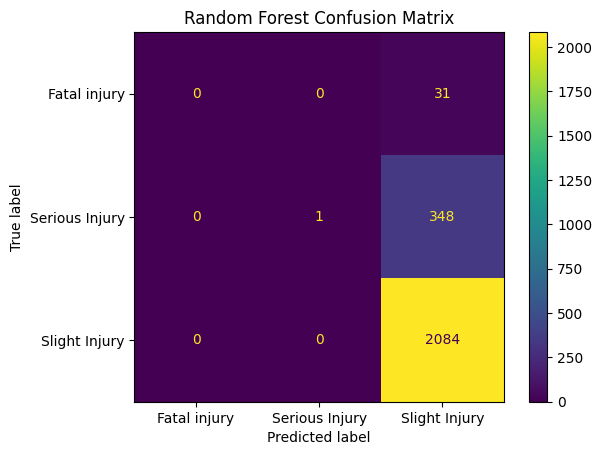

In [55]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=rf_model.classes_
)

disp.plot()
plt.title('Random Forest Confusion Matrix')
plt.show()

**2.Logistic Regression with class balancing**

In [60]:
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline

lr_model = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(
        max_iter=2000,
        class_weight='balanced',
        random_state=42
    ))
])

**Train**

In [61]:
lr_model.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('categorical',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['Day_of_week',
                                                   'Age_band_of_driver',
                                                   'Sex_of_driver',
                                                   'Educational_level',
                                                   'Vehicle_driver_relation',
                                                   'Driving_experience',
                                                   'Type_of_vehicle',
                                                   'Owner_of_vehicle',
                                                   'Service_year_of_vehicle',
                                                   'Defect_of_vehicle',
                                                   'Area_accident_occured',
                                                   'Lanes...
                                                   'Vehicle_movement',
                                                   'Casualty_class',
                                                   'Sex_of_casualty',
                                                   'Age_band_of_casualty',
                                                   'Casualty_severity',
                                                   'Work_of_casuality',
                                                   'Fitness_of_casuality',
                                                   'Pedestrian_movement',
                                                   'Cause_of_accident']),
                                                 ('numerical', 'passthrough',
                                                  ['Number_of_vehicles_involved',
                                                   'Number_of_casualties',
                                                   'Hour'])])),
                ('classifier',
                 LogisticRegression(class_weight='balanced', max_iter=2000,
                                    random_state=42))])

In [62]:
y_pred_lr = lr_model.predict(X_test)

**Evaluate**

In [87]:
from sklearn.metrics import classification_report

print(classification_report(
    y_test,
    y_pred_lr,
    zero_division=0
))

                precision    recall  f1-score   support

  Fatal injury       0.02      0.26      0.04        31
Serious Injury       0.17      0.41      0.24       349
 Slight Injury       0.87      0.52      0.65      2084

      accuracy                           0.50      2464
     macro avg       0.35      0.40      0.31      2464
  weighted avg       0.76      0.50      0.59      2464



**2.Random Forest**

In [68]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline

rf_weighted = Pipeline([
    ('preprocessor', preprocessor_clean),
    ('classifier', RandomForestClassifier(
        n_estimators=300,
        random_state=42,
        class_weight={
            'Slight Injury': 1,
            'Serious Injury': 4,
            'Fatal injury': 10
        },
        n_jobs=-1
    ))
])

In [70]:
rf_weighted.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('categorical',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['Day_of_week',
                                                   'Age_band_of_driver',
                                                   'Sex_of_driver',
                                                   'Educational_level',
                                                   'Vehicle_driver_relation',
                                                   'Driving_experience',
                                                   'Type_of_vehicle',
                                                   'Owner_of_vehicle',
                                                   'Service_year_of_vehicle',
                                                   'Defect_of_vehicle',
                                                   'Area_accident_occured',
                                                   'Lanes...
                                                   'Casualty_severity',
                                                   'Work_of_casuality',
                                                   'Fitness_of_casuality',
                                                   'Pedestrian_movement',
                                                   'Cause_of_accident']),
                                                 ('numerical', 'passthrough',
                                                  ['Number_of_vehicles_involved',
                                                   'Number_of_casualties',
                                                   'Hour'])])),
                ('classifier',
                 RandomForestClassifier(class_weight={'Fatal injury': 10,
                                                      'Serious Injury': 4,
                                                      'Slight Injury': 1},
                                        n_estimators=300, n_jobs=-1,
                                        random_state=42))])

In [ ]:
weighted_pred = rf_weighted.predict(X_test)

In [72]:
y_pred_weighted = rf_weighted.predict(X_test)

In [73]:
from sklearn.metrics import classification_report

print(classification_report(
    y_test,
    y_pred_weighted,
    zero_division=0
))

                precision    recall  f1-score   support

  Fatal injury       0.00      0.00      0.00        31
Serious Injury       1.00      0.01      0.02       349
 Slight Injury       0.85      1.00      0.92      2084

      accuracy                           0.85      2464
     macro avg       0.62      0.34      0.31      2464
  weighted avg       0.86      0.85      0.78      2464



In [75]:
print("Training:")
print(y_train.value_counts())

print("\nTesting:")
print(y_test.value_counts())

Training:
Accident_severity
Slight Injury     8331
Serious Injury    1394
Fatal injury       127
Name: count, dtype: int64

Testing:
Accident_severity
Slight Injury     2084
Serious Injury     349
Fatal injury        31
Name: count, dtype: int64


In [76]:
print("Weighted RF predictions:")
print(pd.Series(y_pred_weighted).value_counts())

print("\nNormal RF predictions:")
print(pd.Series(y_pred).value_counts())

Weighted RF predictions:
Slight Injury     2461
Serious Injury       3
Name: count, dtype: int64

Normal RF predictions:
Slight Injury     2463
Serious Injury       1
Name: count, dtype: int64


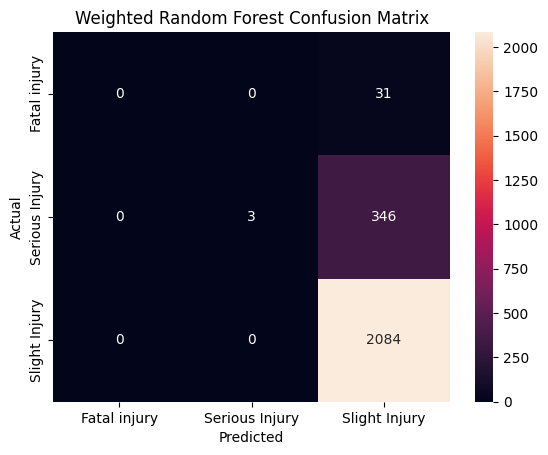

In [77]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred_weighted)

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    xticklabels=rf_weighted.classes_,
    yticklabels=rf_weighted.classes_
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Weighted Random Forest Confusion Matrix")
plt.show()

In [78]:
print("Training class distribution:")
print(y_train.value_counts())

print("\nTesting class distribution:")
print(y_test.value_counts())

Training class distribution:
Accident_severity
Slight Injury     8331
Serious Injury    1394
Fatal injury       127
Name: count, dtype: int64

Testing class distribution:
Accident_severity
Slight Injury     2084
Serious Injury     349
Fatal injury        31
Name: count, dtype: int64


In [79]:
print("Weighted RF predicted classes:")
print(pd.Series(y_pred_weighted).value_counts())

Weighted RF predicted classes:
Slight Injury     2461
Serious Injury       3
Name: count, dtype: int64


**model comparison table**

In [85]:
comparison = pd.DataFrame({
    'Model': [
        'Logistic Regression',
        'Random Forest',
        'Weighted Random Forest'
    ],
    'Accuracy': [0.50, 0.85, 0.85],
    'Macro Precision': [0.35, 0.62, 0.62],
    'Macro Recall': [0.40, 0.33, 0.34],
    'Macro F1': [0.31, 0.31, 0.31]
})

comparison

,Model,Accuracy,Macro Precision,Macro Recall,Macro F1
0,Logistic Regression,0.50,0.35,0.40,0.31
1,Random Forest,0.85,0.62,0.33,0.31
2,Weighted Random Forest,0.85,0.62,0.34,0.31


**Confusion matrices**

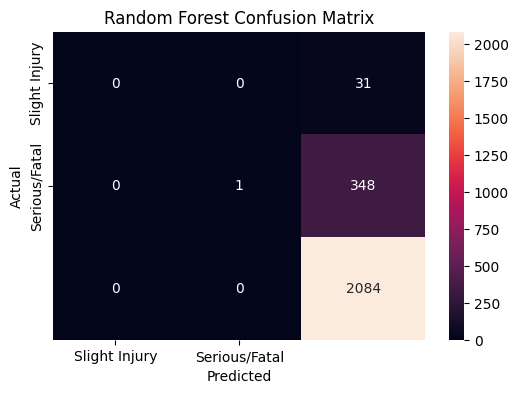

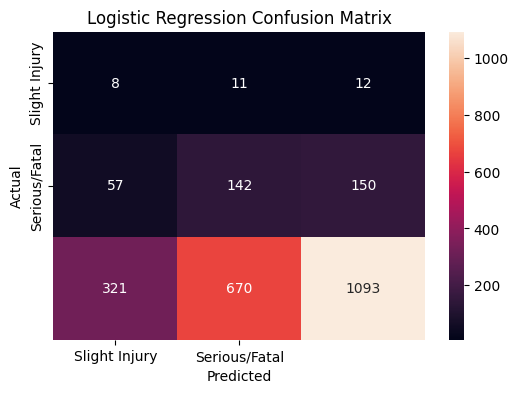

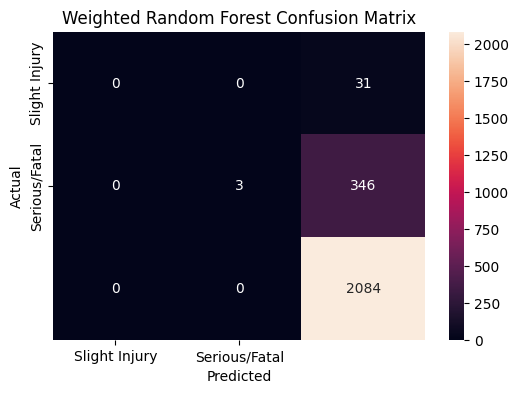

In [93]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

predictions = {
    "Random Forest": y_pred,
    "Logistic Regression": y_pred_lr,
    "Weighted Random Forest": y_pred_weighted,
}

for name, pred in predictions.items():
    cm = confusion_matrix(y_test, pred)

    plt.figure(figsize=(6, 4))
    sns.heatmap(
        cm,
        annot=True,
        fmt='d',
        xticklabels=['Slight Injury', 'Serious/Fatal'],
        yticklabels=['Slight Injury', 'Serious/Fatal']
    )

    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.title(f"{name} Confusion Matrix")
    plt.show()

In [95]:
import pandas as pd

results_df = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest",
        "Weighted Random Forest"
    ],
    "Accuracy": [0.50, 0.85, 0.85],
    "Precision": [0.35, 0.62, 0.62],
    "Recall": [0.40, 0.33, 0.34],
    "F1 Score": [0.31, 0.31, 0.31]
})

print(results_df)

                    Model  Accuracy  Precision  Recall  F1 Score
0     Logistic Regression      0.50       0.35    0.40      0.31
1           Random Forest      0.85       0.62    0.33      0.31
2  Weighted Random Forest      0.85       0.62    0.34      0.31


**Model performance comparison**

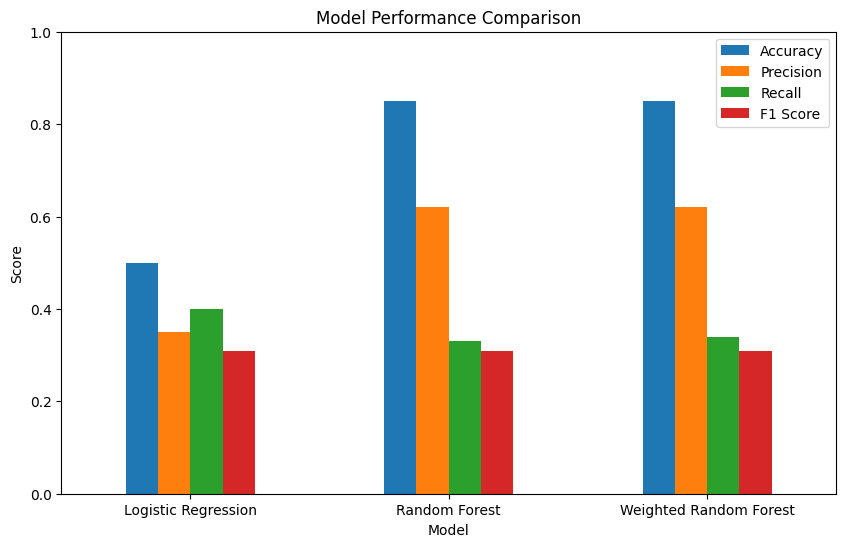

In [96]:
results_df.plot(
    x="Model",
    y=["Accuracy", "Precision", "Recall", "F1 Score"],
    kind="bar",
    figsize=(10, 6)
)

plt.title("Model Performance Comparison")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.legend()
plt.show()

In [97]:
results_df.to_csv("model_comparison.csv", index=False)

In [99]:
rf_model = rf_weighted.named_steps["classifier"]
preprocessor = rf_weighted.named_steps["preprocessor"]

feature_names = preprocessor.get_feature_names_out()

importance = pd.Series(
    rf_model.feature_importances_,
    index=feature_names
).sort_values(ascending=False)

print(importance.head(15))

numerical__Hour                                                                   0.051622
numerical__Number_of_vehicles_involved                                            0.034371
numerical__Number_of_casualties                                                   0.032905
categorical__Types_of_Junction_Y Shape                                            0.011497
categorical__Service_year_of_vehicle_Unknown                                      0.011315
categorical__Work_of_casuality_Driver                                             0.011170
categorical__Age_band_of_driver_31-50                                             0.011054
categorical__Age_band_of_driver_18-30                                             0.010967
categorical__Educational_level_Junior high school                                 0.010881
categorical__Lanes_or_Medians_Two-way (divided with broken lines road marking)    0.010754
categorical__Area_accident_occured_Other                                          0.010690

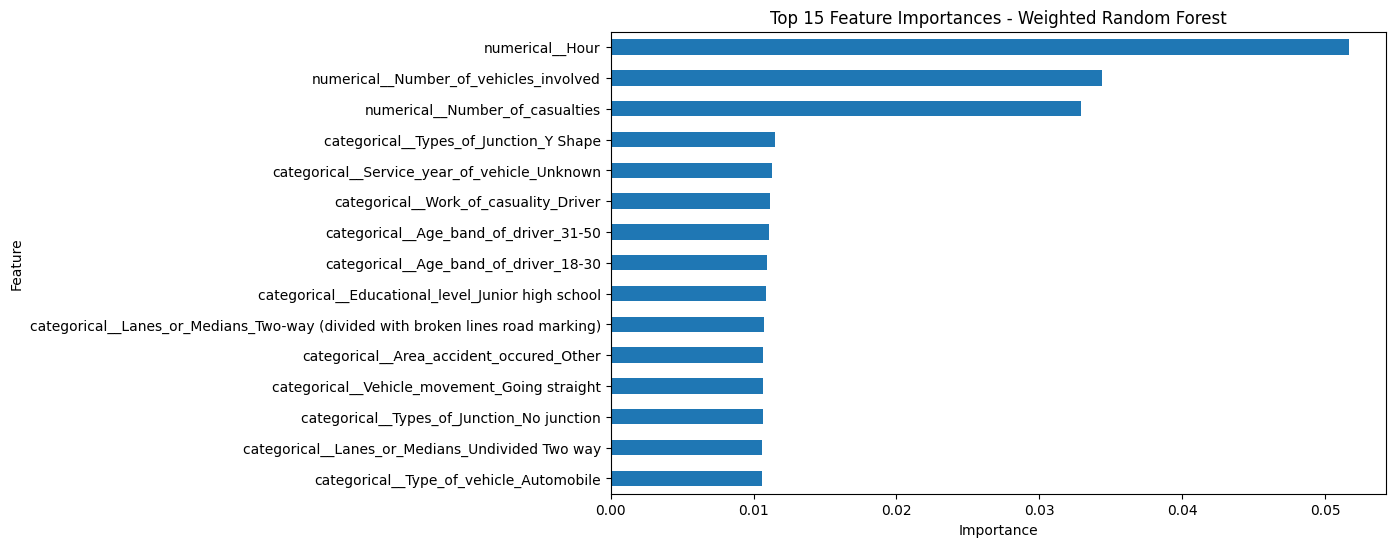

In [100]:
importance.head(15).sort_values().plot(
    kind="barh",
    figsize=(10, 6)
)

plt.title("Top 15 Feature Importances - Weighted Random Forest")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.show()

In [101]:
import joblib

joblib.dump(rf_weighted, "weighted_random_forest.pkl")

['weighted_random_forest.pkl']

**predictions on new data**

In [103]:
new_data = X_test.iloc[[0]]
new_prediction = rf_weighted.predict(new_data)

print(new_prediction)

['Slight Injury']


In [104]:
import joblib

joblib.dump(rf_weighted, "weighted_random_forest.pkl")

print("Model saved successfully!")

Model saved successfully!
